### References

- Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. In Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (pp. 785–794). https://doi.org/10.1145/2939672.2939785
- XGBoost Python API Documentation: https://xgboost.readthedocs.io/

- Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). *Optuna: A Next-generation Hyperparameter Optimization Framework*. KDD '19. https://doi.org/10.1145/3292500.3330701  
- Optuna documentation: https://optuna.org/

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# Ensure reproducibility

In [93]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Data Exploration

In [94]:
df = pd.read_csv("bots_vs_users.csv")
X = df.drop("target", axis=1)
y = df["target"]

In [95]:
display(df)

,has_domain,has_birth_date,has_photo,can_post_on_wall,can_send_message,has_website,gender,has_short_name,has_first_name,has_last_name,...,ads_ratio,avg_views,posting_frequency_days,phone_numbers_ratio,avg_text_uniqueness,city,has_occupation,occupation_type_university,occupation_type_work,has_personal_data
0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
1,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
4,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5869,1.0,1.0,1.0,0.0,0.0,Unknown,2.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Saint Petersburg,1.0,0.0,1.0,Unknown
5870,1.0,Unknown,1.0,0.0,0.0,Unknown,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Saint Petersburg,1.0,1.0,0.0,Unknown
5871,1.0,1.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Saint Petersburg,1.0,1.0,0.0,Unknown
5872,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Moscow,1.0,0.0,1.0,Unknown


In [96]:
# Missing values

nan_counts = df.isna().sum()
unknown_counts = (df == "Unknown").sum()

missing_summary = pd.DataFrame({
    'Data_types': df.dtypes,
    'NaN_count': nan_counts,
    'Unknown_count': unknown_counts
})
missing_summary['Total_missing'] = missing_summary['NaN_count'] + missing_summary['Unknown_count']
missing_summary = missing_summary.sort_values(by='Total_missing', ascending=False)

missing_summary

,Data_types,NaN_count,Unknown_count,Total_missing
has_personal_data,object,0,5006,5006
has_interests,object,0,4601,4601
has_relatives,object,0,4601,4601
has_schools,object,0,4601,4601
has_universities,object,0,4601,4601
marital_status,object,0,4601,4601
has_hometown,object,0,4601,4601
has_military_service,object,0,4601,4601
has_career,object,0,4601,4601
has_music,object,0,4601,4601


In [97]:
categorical_cols = df.select_dtypes(include=['object', 'category'])

category_counts = categorical_cols.nunique().sort_values(ascending=False)

category_summary = pd.DataFrame({
    'Column': category_counts.index,
    'Unique_Categories': category_counts.values
})

category_summary


,Column,Unique_Categories
0,subscribers_count,1597
1,city,362
2,marital_status,9
3,gender,4
4,has_games,3
5,has_movies,3
6,has_activities,3
7,has_music,3
8,can_add_as_friend,3
9,can_invite_to_group,3


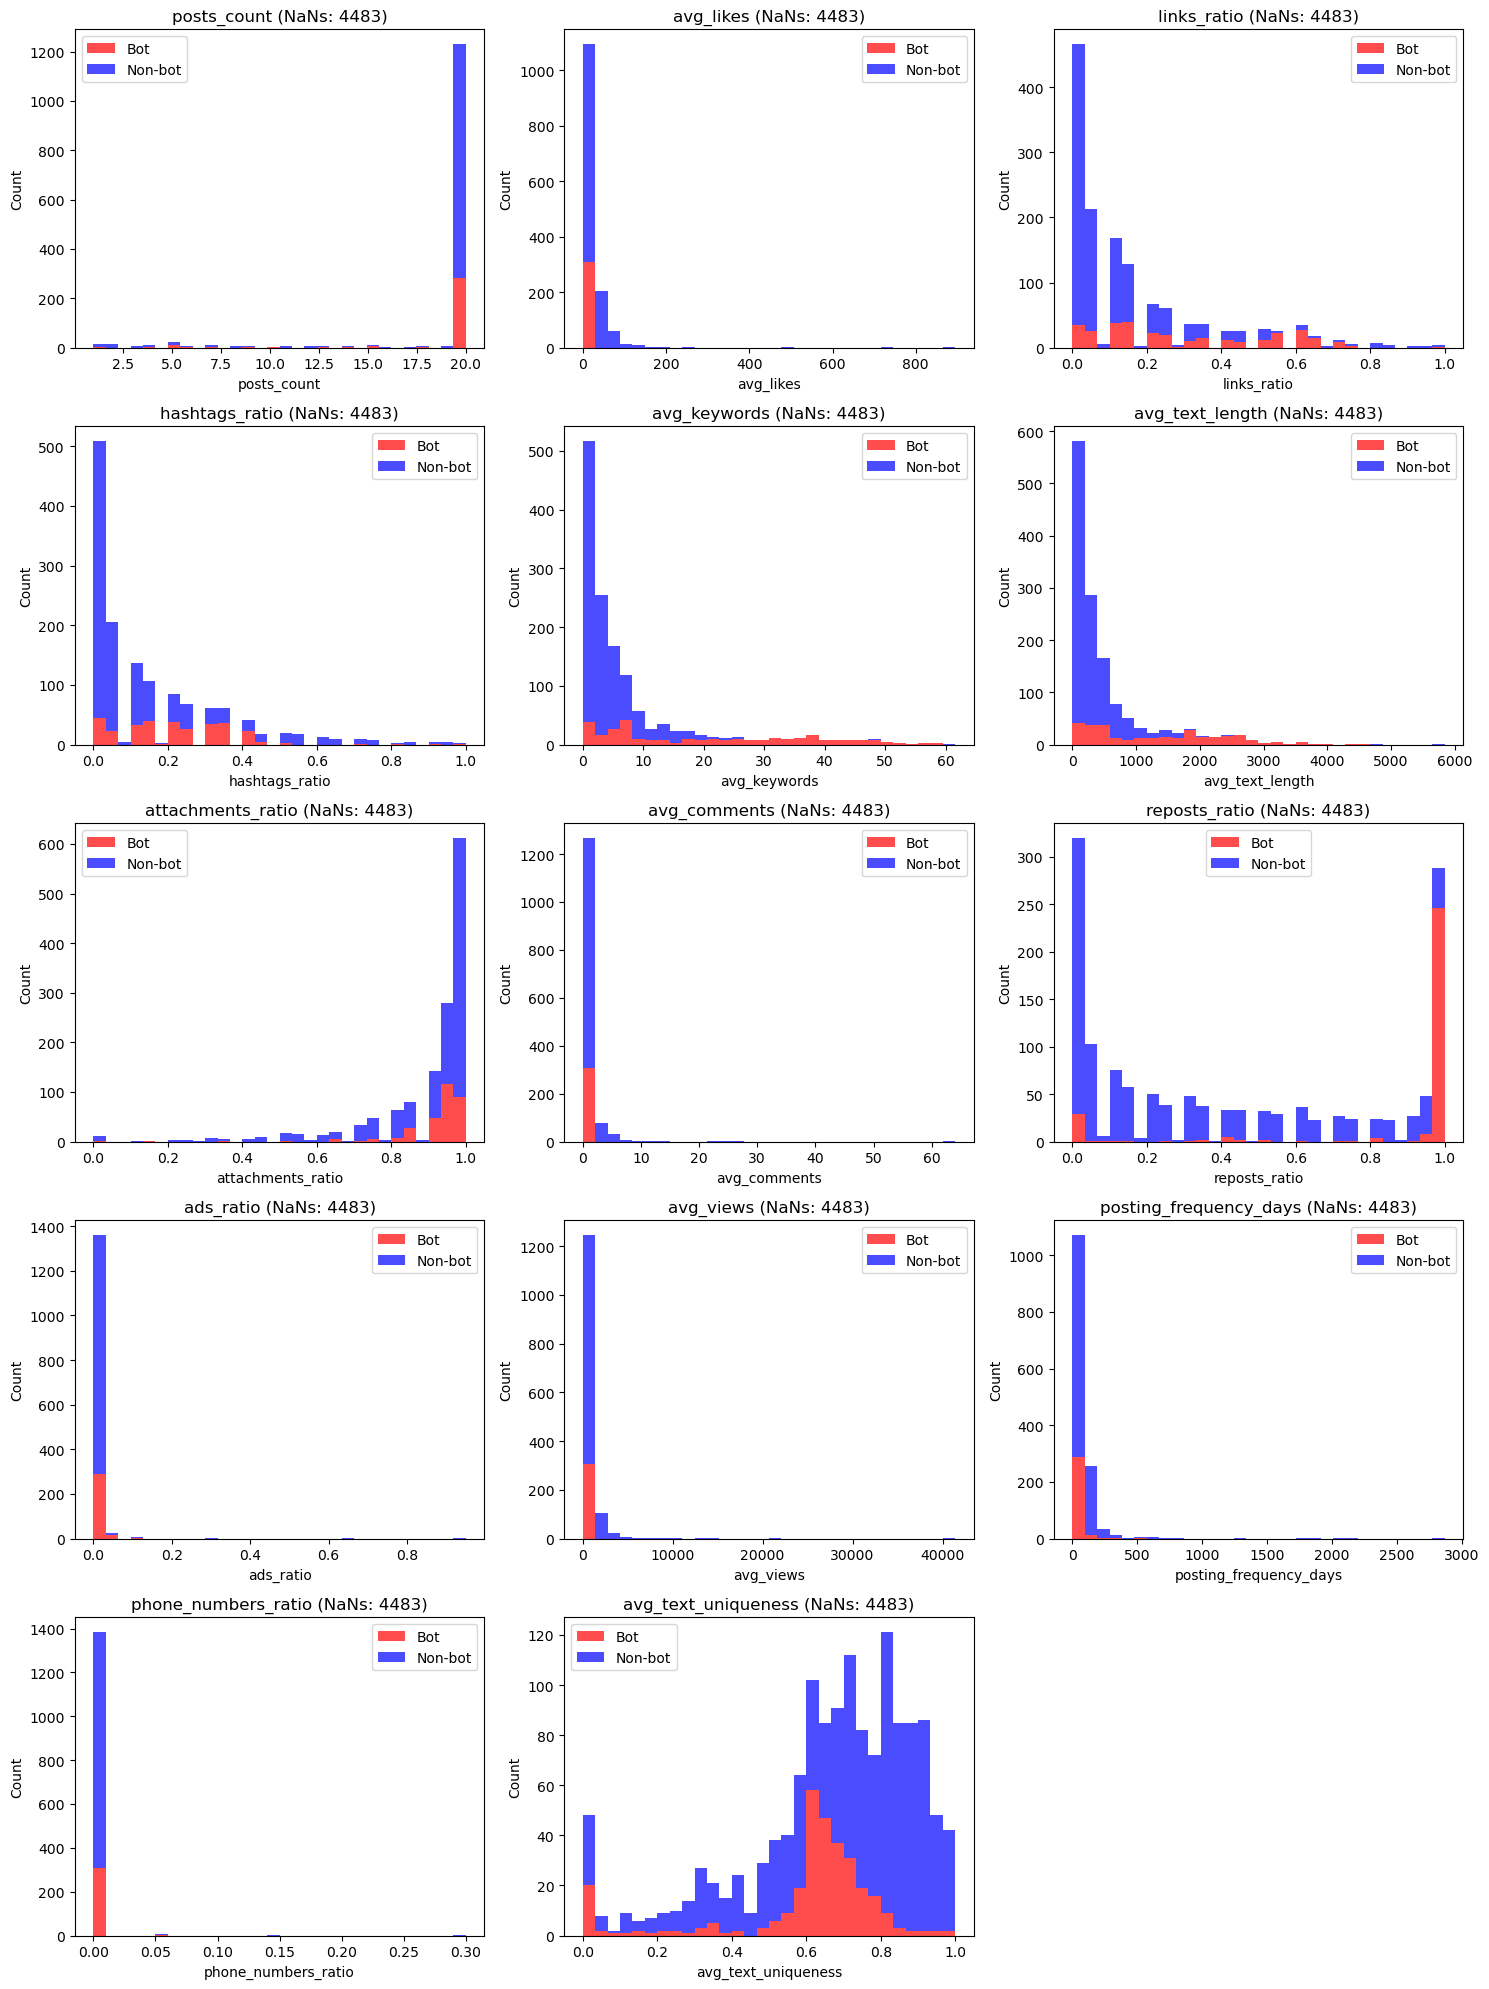

In [98]:
import matplotlib.pyplot as plt

def plot_continuous(X,y):
    continuous_cols = [col for col in X.select_dtypes(include=['float', 'int']).columns 
                    if X[col].nunique() > 0]

    n_cols = 3
    n_rows = (len(continuous_cols) + n_cols - 1) // n_cols
    plt.figure(figsize=(n_cols * 5, n_rows * 4))

    for i, col in enumerate(continuous_cols, 1):
        plt.subplot(n_rows, n_cols, i)

        data = X[col].dropna()

        bot_data = data[y == 1]
        non_bot_data = data[y == 0]

        plt.hist([bot_data, non_bot_data], bins=30, stacked=True, label=['Bot', 'Non-bot'], alpha=0.7, color=["r", "b"])
        plt.title(f"{col} (NaNs: {X[col].isna().sum()})")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.legend()

    plt.tight_layout()
    plt.show()

plot_continuous(X,y)

In [99]:
# Check if all continuous values are missing for the same rows
continuous_cols = [col for col in df.select_dtypes(include=['float', 'int']).columns if col != 'target']
rows_all_continuous_nan = df[continuous_cols].isna().all(axis=1)
print(rows_all_continuous_nan.sum())

users_with_no_continuous_data = df[rows_all_continuous_nan]

4483


In [100]:
categorical_cols = df.select_dtypes(include=['object']).columns

# Count 'Unknown' per row
unknown_counts = users_with_no_continuous_data[categorical_cols].apply(lambda row: (row == 'Unknown').sum(), axis=1)

users_with_no_continuous_data = users_with_no_continuous_data.copy()
users_with_no_continuous_data['num_unknown_categoricals'] = unknown_counts

In [101]:
users_with_data = df[~rows_all_continuous_nan]
unknown_counts_with_data = users_with_data[categorical_cols].apply(lambda row: (row == 'Unknown').sum(), axis=1)

print("Users with NO continuous data:")
print(users_with_no_continuous_data['num_unknown_categoricals'].describe())

print("\nUsers WITH continuous data:")
print(unknown_counts_with_data.describe())


Users with NO continuous data:
count    4483.000000
mean       25.453714
std         9.573049
min         0.000000
25%        19.000000
50%        32.000000
75%        33.000000
max        45.000000
Name: num_unknown_categoricals, dtype: float64

Users WITH continuous data:
count    1391.000000
mean        8.828181
std         8.453084
min         0.000000
25%         1.000000
50%         5.000000
75%        17.000000
max        45.000000
dtype: float64


In [102]:
print("Bot rate (target=1) among users with NO continuous data:")
print(users_with_no_continuous_data['target'].value_counts(normalize=True))

print("\nBot rate among users WITH continuous data:")
print(users_with_data['target'].value_counts(normalize=True))


Bot rate (target=1) among users with NO continuous data:
target
1    0.586438
0    0.413562
Name: proportion, dtype: float64

Bot rate among users WITH continuous data:
target
0    0.778577
1    0.221423
Name: proportion, dtype: float64


In [103]:
# Count number of users per city
city_counts = df['city'].value_counts()

frequent_cities = city_counts[city_counts >= 30]

print(f"{len(frequent_cities)} cities have at least 30 users.")
print(frequent_cities)


5 cities have at least 30 users.
city
Unknown             2780
Saint Petersburg    1549
Kostomuksha          405
Moscow               335
Petrozavodsk         103
Name: count, dtype: int64


In [104]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_subscriber_count_distribution(df, column='subscribers_count', bins=50):
    print("Top subscriber counts (excluding NaN):")
    print(df[column].value_counts().sort_index().head(10))
    
    nan_count = df[column].isna().sum()
    total = len(df)
    print(f"\nNaNs: {nan_count} ({nan_count / total:.2%} of total)")

    plt.figure(figsize=(8, 5))
    df[column].dropna().plot(kind='hist', bins=bins, edgecolor='black')
    plt.title(f"Distribution of {column} (excluding NaNs)")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# plot_subscriber_count_distribution(df)


In [105]:
df["target"].value_counts()

target
1    2937
0    2937
Name: count, dtype: int64

# Data preprocessing

In [106]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

In [107]:
# Train/test split
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

In [108]:
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler
from sklearn.impute import SimpleImputer

class DataCleaner:
    def __init__(self, scaler="standard", DT=False):
        self.scaler_collumns = None
        self.transform_map = {}
        self.DT = DT
        self.imputer = SimpleImputer(strategy='median')

        if scaler == "standard":
            self.scaler = StandardScaler()
        elif scaler == "robust":
            self.scaler = RobustScaler()
        elif scaler == "yeo-johnson":
            self.scaler = PowerTransformer(method='yeo-johnson', standardize=True)

    def transform(self, X): # For X_test (after fit_transform has been called)
        continuous_cols = X.select_dtypes(include=['float', 'int']).columns
        X_con = X[continuous_cols].copy()
        X_cat = X.drop(columns=continuous_cols).copy()
        X_cat = self.add_minimal_profile_flag(X_con, X_cat)
        X_con, X_cat = self.subs_to_continuous(X_con, X_cat)
        if not self.DT:
            X_con = pd.DataFrame(self.scaler.transform(X_con), columns=X_con.columns, index=X_con.index)
            X_con = pd.DataFrame(self.imputer.transform(X_con), columns=X_con.columns, index=X_con.index)
        for col in self.cat_transform:
            transformed = self.cat_transform[col](X_cat[col])
            X_cat = X_cat.drop(columns=[col])
            X_cat = pd.concat([X_cat, transformed], axis=1)
        return pd.concat([X_con, X_cat], axis=1)

    def fit_transform(self, X): # For X_train (learns features for transformation)
        continuous_cols = X.select_dtypes(include=['float', 'int']).columns
        X_con = X[continuous_cols].copy()
        X_cat = X.drop(columns=continuous_cols).copy()
        X_cat = self.add_minimal_profile_flag(X_con, X_cat)
        X_con, X_cat = self.subs_to_continuous(X_con, X_cat)
        if not self.DT:
            X_con = pd.DataFrame(self.scaler.fit_transform(X_con), columns=X_con.columns, index=X_con.index)
            X_con = pd.DataFrame(self.imputer.fit_transform(X_con), columns=X_con.columns, index=X_con.index)
        X_cat = self.one_hot_encode_thresholded(X_cat)
        return pd.concat([X_con, X_cat], axis=1)

    def add_minimal_profile_flag(self, X_con, X_cat): # Add feature identifying users without categorical features
        X_cat['is_minimal_profile'] = X_con.isna().all(axis=1).astype(int)
        return X_cat

    def subs_to_continuous(self, X_con, X_cat): # Turn subscriber count into continuous var
        # Clean the column: remove commas, spaces, and convert to numeric
        X_con['subscribers_count'] = pd.to_numeric(
            X_cat['subscribers_count']
            .replace("Unknown", np.nan)
            .astype(str)
            .str.replace(r"[^\d.]", "", regex=True)
            .replace("", np.nan)  # Handle empty strings from non-numeric entries
        )

        # Drop the temp column
        X_cat.drop(columns='subscribers_count', inplace=True)
        
        return X_con, X_cat

    def one_hot_encode_thresholded(self, X_cat, min_count=30):
        self.cat_transform = {}

        for col in X_cat.columns:
            num_cats = X_cat[col].nunique(dropna=False)

            if num_cats == 2:
                
                def transform():
                    # During fitting (on train)
                    categories = X_cat[col].astype("category").cat.categories
                    mapping = {cat: i for i, cat in enumerate(categories)}
                    
                    def inner(series):
                        unknowns = ~series.isin(mapping)
                        if unknowns.any():
                            print(
                                f"Unknown categories found in column '{col}' during transform. "
                                "They will be mapped to index 0."
                            )
                        return series.map(mapping).fillna(0).astype(int)
                    
                    return inner

                transformer = transform()
                self.cat_transform[col] = transformer
                transformed = transformer(X_cat[col])
                X_cat = X_cat.drop(columns=[col])
                X_cat = pd.concat([X_cat, transformed], axis=1)

            if num_cats > 2:
                def transform():
                    value_counts = X_cat[col].value_counts()
                    frequent_cats = value_counts[value_counts >= min_count].index.tolist()
                    has_rare = len(value_counts[value_counts < min_count]) > 0
                    expected_cols = [f"{col}_{cat}" for cat in (["other"] if has_rare else []) + frequent_cats]
                    column_name = col

                    def inner(series):
                        series = series.where(series.isin(frequent_cats), "other")

                        dummies = pd.get_dummies(series, prefix=column_name).astype(int)

                        for missing in set(expected_cols) - set(dummies.columns):
                            print(f"Expected category '{missing}' not found in data — filling with 0s")
                            dummies[missing] = 0

                        return dummies[expected_cols]

                    return inner


                transformer = transform()
                self.cat_transform[col] = transformer
                transformed = transformer(X_cat[col])
                X_cat = X_cat.drop(columns=[col])
                X_cat = pd.concat([X_cat, transformed], axis=1)

        return X_cat


In [109]:
# Testing if data split worked

def test_cleaner():
    test = pd.read_csv("bots_vs_users.csv")
    test = test[["avg_text_length", "subscribers_count", "city", "has_photo", "has_domain"]]
    display(test) #.sort_values("subscribers_count", ascending=False))
    #plot_continuous(test, y)
    cleaner = DataCleaner("yeo-johnson", DT=False)
    transformed1 = cleaner.fit_transform(test)
    display(transformed1)
    transformed = cleaner.transform(test)
    display(transformed) #.sort_values("subscribers_count", ascending=False))
    plot_continuous(transformed, y)

def test_test():
    test = pd.read_csv("bots_vs_users.csv")
    test_short = test[["avg_text_length", "subscribers_count", "city", "has_photo", "has_domain"]]
    
    cleaner = DataCleaner("yeo-johnson")
    transformed_train = cleaner.fit_transform(test_short)
    transformed_test = cleaner.transform(test_short)

    if transformed_train.equals(transformed_test):
        print("✅ DataFrames are exactly equal.")
        return

    print("❌ DataFrames are NOT equal")

test_test()

✅ DataFrames are exactly equal.


In [ ]:
cleaner_NN = DataCleaner("yeo-johnson", DT=False)
X_train_NN = cleaner_NN.fit_transform(X_train)
X_test_NN = cleaner_NN.transform(X_test)

# display(X_train_NN)
# plot_continuous(X_train_NN, y)

Expected category 'is_confirmed_other' not found in data — filling with 0s


# Determine Baseline Performance

In [111]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

dummy = DummyClassifier(strategy="stratified", random_state=SEED)
dummy.fit(X_train_NN, y_train)
print(classification_report(y_test, dummy.predict(X_test_NN), zero_division=0))


              precision    recall  f1-score   support

           0       0.50      0.51      0.50       588
           1       0.50      0.49      0.49       587

    accuracy                           0.50      1175
   macro avg       0.50      0.50      0.50      1175
weighted avg       0.50      0.50      0.50      1175



# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report

param_grid = {
    'C': [0.01, 0.1, 0.25, 0.5, 1, 2.5, 5, 10, 20, 40, 80],
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=SEED),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1 # use all available cores
)

grid_search.fit(X_train_NN, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_NN)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)


Best Hyperparameters: {'C': 2.5}
Best score: 0.9746707322629655


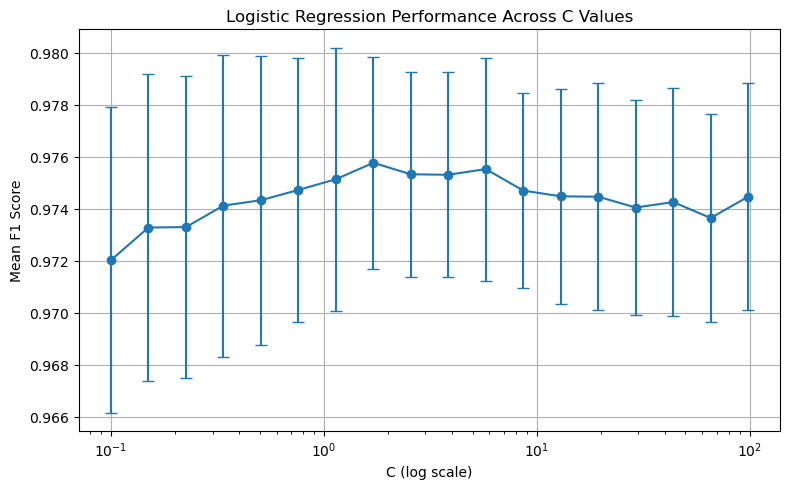

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score
import re

C_values = []
c = 0.1
while c < 100:
    C_values.append(c)
    c *= 1.5

# C_values = [0.5, 1, 1.5, 2, 2.5, 3.5, 5, 7.5, 10, 15, 20, 25, 30, 40, 50]

results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scorer = make_scorer(f1_score)

for C in C_values:
    model = LogisticRegression(C=C, random_state=SEED)
    f1_scores = cross_val_score(model, X_train_NN, y_train, cv=cv, scoring=scorer)
    results.append({
        'C': C,
        'f1_mean': np.mean(f1_scores),
        'f1_std': np.std(f1_scores)
    })

results_df = pd.DataFrame(results)

plt.figure(figsize=(8, 5))
plt.errorbar(results_df['C'], results_df['f1_mean'], yerr=results_df['f1_std'], fmt='o-', capsize=4)
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Mean F1 Score')
title = 'Logistic Regression Performance Across C Values'
plt.title(title)
plt.grid(True)
plt.tight_layout()
plt_name = re.sub(r'[^\w\.]', '_', title)
plt.savefig(f"Figures/{plt_name}.png")
plt.show()


In [115]:
import pandas as pd
import numpy as np

# Assuming your model is trained:
model = best_model  # your trained LogisticRegression
feature_names = X_train_NN.columns  # or a list of feature names

# Get coefficients and match with feature names
coef = model.coef_[0]  # For binary classification
feature_importance = pd.Series(coef, index=feature_names)

# Sort by absolute importance
important_features = feature_importance.abs().sort_values(ascending=False)

print("Top important features:")
print(important_features.head(10))


Top important features:
city_Kostomuksha       3.647924
has_status_Unknown     2.623826
has_status_1.0         2.367796
has_website_1.0        2.285121
city_Unknown           2.174295
city_Moscow            2.050257
city_other             2.008561
has_last_name_other    1.983850
city_Petrozavodsk      1.786433
has_website_Unknown    1.412861
dtype: float64


# Train Models

## XGBoost

In [116]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Too many combinations! → Can't run it locally in reasonable time
param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 6, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 1.0],
    'gamma': [0, 1, 5],
    'lambda': [0, 1, 10],
    'alpha': [0, 1, 10],
    'scale_pos_weight': [1, 10]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)

# grid_search.fit(X_train_NN, y_train)

# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test_NN)

# print("Best Hyperparameters:", grid_search.best_params_)
# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))


In [ ]:
import xgboost as xgb
import optuna

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        #'lambda': trial.suggest_float('lambda', 0, 10),
        #'alpha': trial.suggest_float('alpha', 0, 10),
        #'scale_pos_weight': trial.suggest_categorical('scale_pos_weight', [1, 10]),
    }
    model = xgb.XGBClassifier(**param, eval_metric='logloss')

    # Ensure reproducibility while maintaining variation
    cv_seed = SEED * trial.number
    scores = []
    for j in range(5):
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=cv_seed)
        scores.append(cross_val_score(model, X_train_NN, y_train, cv=cv, scoring='f1').mean())
        cv_seed += 1
    score = np.mean(scores)
    return score

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=100)

print("Best parameters:", study.best_params)
print("Best f1:", study.best_value)

[I 2025-05-12 15:26:29,494] A new study created in memory with name: no-name-afcfe59c-32eb-4263-abea-b5535d2b50da
[I 2025-05-12 15:26:34,946] Trial 0 finished with value: 0.9750068446813953 and parameters: {'n_estimators': 218, 'learning_rate': 0.28570714885887566, 'max_depth': 7, 'min_child_weight': 3, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'gamma': 0.2904180608409973}. Best is trial 0 with value: 0.9750068446813953.
[I 2025-05-12 15:26:39,882] Trial 1 finished with value: 0.9764296093383369 and parameters: {'n_estimators': 440, 'learning_rate': 0.18432335340553055, 'max_depth': 7, 'min_child_weight': 1, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'gamma': 1.0616955533913808}. Best is trial 1 with value: 0.9764296093383369.
[I 2025-05-12 15:26:42,814] Trial 2 finished with value: 0.9753975441029098 and parameters: {'n_estimators': 132, 'learning_rate': 0.06318730785749581, 'max_depth': 4, 'min_child_weight': 3, 'subsample':

Best parameters: {'n_estimators': 281, 'learning_rate': 0.20027350171988462, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.9283798467146143, 'colsample_bytree': 0.6527097019835404, 'gamma': 1.061798113663353}
Best f1: 0.9780822410690199


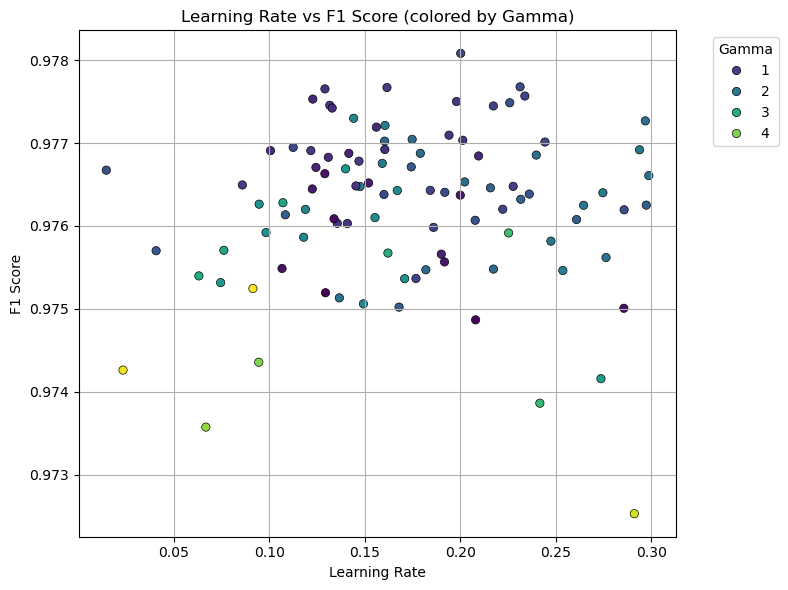

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

trials_df = study.trials_dataframe(attrs=('number', 'value', 'params'))

trials_df.columns = [col.replace("params_", "") for col in trials_df.columns]
for col in ['learning_rate', 'gamma']:
    trials_df[col] = pd.to_numeric(trials_df[col], errors='coerce')

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=trials_df,
    x='learning_rate',
    y='value',
    hue='gamma',
    palette='viridis',
    edgecolor='black'
)
plt.xlabel('Learning Rate')
plt.ylabel('F1 Score')
title = 'Learning Rate vs F1 Score (colored by Gamma)'
plt.title(title)
plt.legend(title='Gamma', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt_name = re.sub(r'[^\w\.]', '_', title)
plt.savefig(f"Figures/{plt_name}.png")
plt.show()


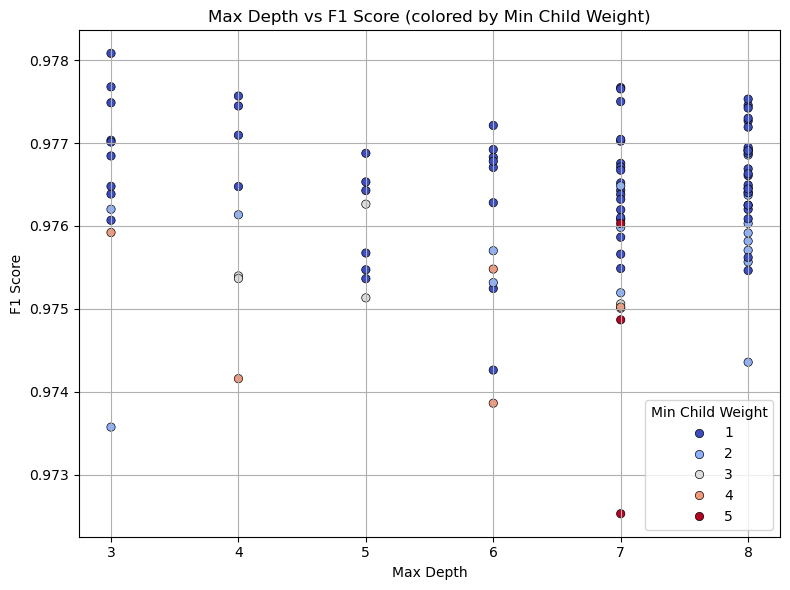

In [43]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=trials_df,
    x='max_depth',
    y='value',
    hue='min_child_weight',
    palette='coolwarm',
    edgecolor='black'
)
plt.xlabel('Max Depth')
plt.ylabel('F1 Score')
plt.title('Max Depth vs F1 Score (colored by Min Child Weight)')
plt.legend(title='Min Child Weight')
plt.grid(True)
plt.tight_layout()
plt.show()


# Results

## Logistic regression

Logistic Regression Performance:
Accuracy:  0.9728
Precision: 0.9843
Recall:    0.9608
F1 Score:  0.9724
AUC:       0.9951


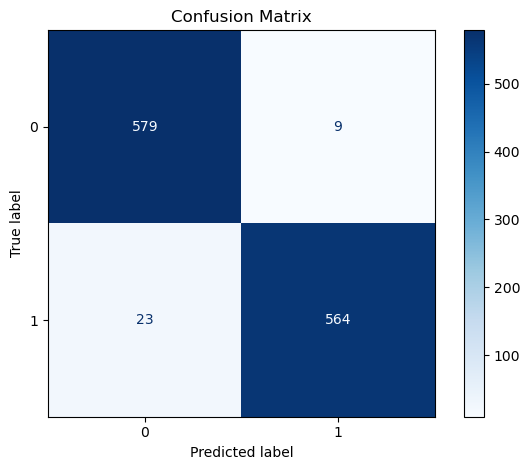

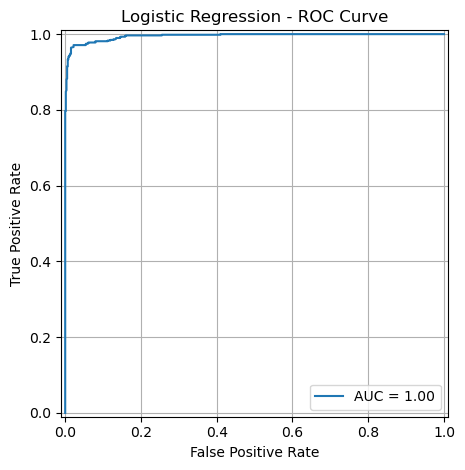

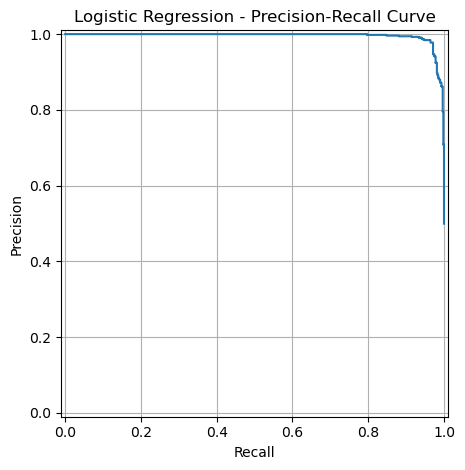

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
import matplotlib.pyplot as plt

# 1. Train final model
final_regressor = LogisticRegression(C=2.5, max_iter=1000, random_state=42)
final_regressor.fit(X_train_NN, y_train)

# 2. Predict labels and probabilities
y_pred_log = final_regressor.predict(X_test_NN)
y_proba_log = final_regressor.predict_proba(X_test_NN)[:, 1]

# 3. Compute metrics
acc = accuracy_score(y_test, y_pred_log)
prec = precision_score(y_test, y_pred_log)
rec = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)
auc = roc_auc_score(y_test, y_proba_log)

# 4. Print metrics
print("Logistic Regression Performance:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

# 5. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_log)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc).plot()
title = "Logistic Regression - ROC Curve"
plt.title(title)
plt.grid(True)
plt.tight_layout()
plt_name = re.sub(r'[^\w\.]', '_', title)
plt.savefig(f"Figures/{plt_name}.png")
plt.show()

# 7. Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba_log)
PrecisionRecallDisplay(precision=precision, recall=recall).plot()
title = "Logistic Regression - Precision-Recall Curve"
plt.title(title)
plt.grid(True)
plt.tight_layout()
plt_name = re.sub(r'[^\w\.]', '_', title)
plt.savefig(f"Figures/{plt_name}.png")
plt.show()


## XGBoost

/Users/eliasschlie/anaconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [18:54:23] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1745056743506/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Performance:
Accuracy:  0.9770
Precision: 0.9861
Recall:    0.9676
F1 Score:  0.9768
AUC:       0.9962


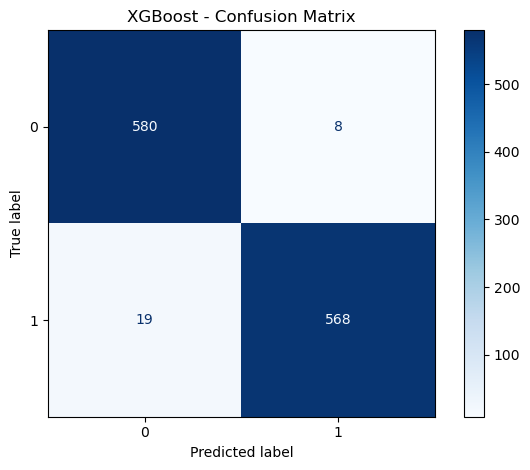

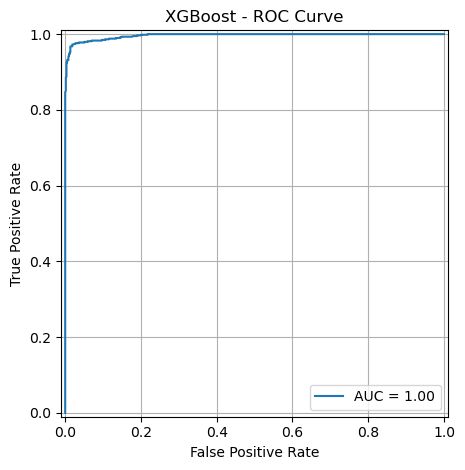

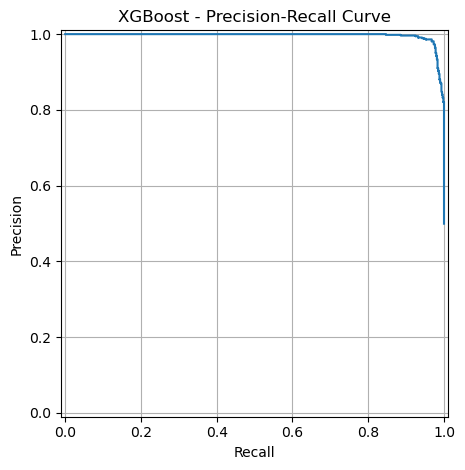

In [ ]:
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
import matplotlib.pyplot as plt

# 1. Define and train the XGBoost classifier
xgb_params = {
    'n_estimators': 281,
    'learning_rate': 0.20027350171988462,
    'max_depth': 3,
    'min_child_weight': 1,
    'subsample': 0.9283798467146143,
    'colsample_bytree': 0.6527097019835404,
    'gamma': 1.061798113663353,
    'eval_metric': 'logloss',
    'random_state': 42
}

final_xgb = xgb.XGBClassifier(**xgb_params)
final_xgb.fit(X_train_NN, y_train)

# 2. Predict labels and probabilities
y_pred_xgb = final_xgb.predict(X_test_NN)
y_proba_xgb = final_xgb.predict_proba(X_test_NN)[:, 1]

# 3. Compute metrics
acc = accuracy_score(y_test, y_pred_xgb)
prec = precision_score(y_test, y_pred_xgb)
rec = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
auc = roc_auc_score(y_test, y_proba_xgb)

# 4. Print metrics
print("XGBoost Performance:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

# 5. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("XGBoost - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc).plot()
title = "XGBoost - ROC Curve"
plt.title(title)
plt.grid(True)
plt.tight_layout()
plt_name = re.sub(r'[^\w\.]', '_', title)
plt.savefig(f"Figures/{plt_name}.png")
plt.show()

# 7. Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba_xgb)
PrecisionRecallDisplay(precision=precision, recall=recall).plot()
title = "XGBoost - Precision-Recall Curve"
plt.title(title)
plt.grid(True)
plt.tight_layout()
plt_name = re.sub(r'[^\w\.]', '_', title)
plt.savefig(f"Figures/{plt_name}.png")
plt.show()


## Discussion

In [ ]:
import pandas as pd
import numpy as np

feature_names = X_train_NN.columns
coefs = final_regressor.coef_[0]

feature_importance = pd.Series(coefs, index=feature_names).sort_values(key=np.abs, ascending=False)

print("Top 10 most important features (by absolute weight):")
print(feature_importance.head(10))

Top 10 most important features (by absolute weight):
city_Kostomuksha      -3.647924
has_status_Unknown     2.623826
has_status_1.0        -2.367796
has_website_1.0       -2.285121
city_Unknown           2.174295
city_Moscow            2.050257
city_other             2.008561
has_last_name_other   -1.983850
city_Petrozavodsk     -1.786433
has_website_Unknown    1.412861
dtype: float64


In [ ]:

importance_dict = final_xgb.get_booster().get_score(importance_type='gain')

feature_importance = pd.Series(importance_dict).sort_values(ascending=False)

latex_table = feature_importance.head(10).to_latex(float_format="%.3f", caption="Descriptive Statistics", label="tab:desc_stats")
print(latex_table)



importance_dict = final_xgb.get_booster().get_score(importance_type='weight')

feature_importance = pd.Series(importance_dict).sort_values(ascending=False)

latex_table = feature_importance.head(10).to_latex(float_format="%.3f", caption="Descriptive Statistics", label="tab:desc_stats")
print(latex_table)



\begin{table}
\caption{Descriptive Statistics}
\label{tab:desc_stats}
\begin{tabular}{lr}
\toprule
 & 0 \\
\midrule
has_photo_0.0 & 741.480 \\
has_mobile_Unknown & 366.661 \\
has_status_Unknown & 354.188 \\
all_posts_visible_Unknown & 232.566 \\
subscribers_count & 37.060 \\
avg_likes & 33.168 \\
city_Saint Petersburg & 27.401 \\
has_website_0.0 & 26.403 \\
has_occupation & 18.723 \\
has_status_0.0 & 16.661 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Descriptive Statistics}
\label{tab:desc_stats}
\begin{tabular}{lr}
\toprule
 & 0 \\
\midrule
subscribers_count & 32.000 \\
posting_frequency_days & 23.000 \\
has_status_Unknown & 19.000 \\
city_Kostomuksha & 18.000 \\
city_Saint Petersburg & 17.000 \\
avg_views & 13.000 \\
has_birth_date & 13.000 \\
city_other & 11.000 \\
gender_1.0 & 11.000 \\
posts_count & 11.000 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
import shap

explainer = shap.Explainer(final_xgb, X_train_NN)
shap_values = explainer(X_test_NN)

shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title("XGBoost - SHAP Beeswarm Plot", fontsize=14)
plt.tight_layout()
plt.savefig("Figures/xgb_shap_beeswarm.png", dpi=300, bbox_inches='tight')
plt.close()

shap.plots.bar(shap_values, max_display=10, show=False)
plt.title("XGBoost - SHAP Feature Importance (Mean |SHAP|)", fontsize=14)
plt.tight_layout()
plt.savefig("Figures/xgb_shap_bars.png", dpi=300, bbox_inches='tight')
plt.close()


In [74]:
import shap

explainer = shap.Explainer(final_regressor, X_train_NN, feature_names=feature_names)
shap_values = explainer(X_test_NN)

# Beeswarm plot
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title("Logistic Regression - SHAP Beeswarm Plot", fontsize=14)
plt.tight_layout()
plt.savefig("Figures/shap_beeswarm.png", dpi=300, bbox_inches='tight')
plt.close()

# Bar plot
shap.plots.bar(shap_values, max_display=10, show=False)
plt.title("Logistic Regression - SHAP Feature Importance (Mean |SHAP|)", fontsize=14)
plt.tight_layout()
plt.savefig("Figures/shap_bars.png", dpi=300, bbox_inches='tight')
plt.close()


In [ ]:
y_pred_log = final_regressor.predict(X_test_NN)
y_pred_xgb = final_xgb.predict(X_test_NN)

log_error = (y_pred_log != y_test).astype(int)
xgb_error = (y_pred_xgb != y_test).astype(int)

df_test = X_test_NN.copy()
df_test['gender'] = X_test_NN.apply(lambda row: (
    '1.0' if row.get('gender_1.0') == 1 else
    '2.0' if row.get('gender_2.0') == 1 else
    'other' if row.get('gender_other') == 1 else
    'unknown'
), axis=1)

df_test['log_error'] = log_error
df_test['xgb_error'] = xgb_error

gender_counts = df_test['gender'].value_counts().sort_index()

error_sums = df_test.groupby('gender')[['log_error', 'xgb_error']].sum()

summary = error_sums.copy()
summary['Total Members'] = gender_counts
summary['LR Error Rate'] = summary['log_error'] / summary['Total Members']
summary['XGB Error Rate'] = summary['xgb_error'] / summary['Total Members']

summary = summary.rename(columns={
    'log_error': 'LR Errors',
    'xgb_error': 'XGB Errors'
})

print("Error counts, total samples, and error rates by gender:")
print(summary.to_latex(float_format="%.3f", caption="Error counts, total samples, and error rates by gender", label="tab:gender_analysis"))


Error counts, total samples, and error rates by gender:
\begin{table}
\caption{Error counts, total samples, and error rates by gender}
\label{tab:gender_analysis}
\begin{tabular}{lrrrrr}
\toprule
 & LR Errors & XGB Errors & Total Members & LR Error Rate & XGB Error Rate \\
gender &  &  &  &  &  \\
\midrule
1.0 & 19 & 17 & 888 & 0.021 & 0.019 \\
2.0 & 12 & 9 & 278 & 0.043 & 0.032 \\
other & 1 & 1 & 9 & 0.111 & 0.111 \\
\bottomrule
\end{tabular}
\end{table}

